# 🛠️ environement setup

In [ ]:
!git clone https://github.com/domguia/thinker

Cloning into 'thinker'...
remote: Enumerating objects: 397, done.
remote: Counting objects: 100% (167/167), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 397 (delta 100), reused 119 (delta 55), pack-reused 230 (from 1)
Receiving objects: 100% (397/397), 2.76 MiB | 6.36 MiB/s, done.
Resolving deltas: 100% (213/213), done.


In [ ]:
pip install -q torchinfo lightning torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.2/869.2 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 16.5 MB/s eta 0:00:00


In [ ]:
pip install -q transformers accelerate

In [ ]:
# pip install torch_xla cloud-tpu-client https://storage.googleapis.com/tpu-pytorch/wheels/colab/torch_xla-2.0-cp310-cp310-linux_x86_64.whl

In [ ]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

In [ ]:
%tensorboard --logdir /content/thinker/lightning_logs/

## download data
wiki data from [saleforce](https://blog.salesforceairesearch.com/the-wikitext-long-term-dependency-language-modeling-dataset/)

In [ ]:
# !wget -P /content/thinker/data "https://s3.amazonaws.com/research.metamind.io/wikitext/wikitext-2-raw-v1.zip"
# !wget "https://s3.amazonaws.com/research.metamind.io/wikitext/wikitext-103-raw-v1.zip"
!unzip "/content/thinker/data/wikitext-2-raw-v1.zip" -d /content/thinker/data/wikitext-2-raw-v1/

Archive:  /content/thinker/data/wikitext-2-raw-v1.zip
   creating: /content/thinker/data/wikitext-2-raw-v1/wikitext-2-raw/
  inflating: /content/thinker/data/wikitext-2-raw-v1/wikitext-2-raw/wiki.test.raw  
  inflating: /content/thinker/data/wikitext-2-raw-v1/wikitext-2-raw/wiki.valid.raw  
  inflating: /content/thinker/data/wikitext-2-raw-v1/wikitext-2-raw/wiki.train.raw  


In [ ]:
%cd /content/thinker

/content/thinker


In [ ]:
%run generate-embedding.py -m "phi1.5" --cuda 1

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/2.84G [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


TypeError: PhiForCausalLM.__init__() got an unexpected keyword argument 'flash_attn'

## ⬇️ git pull

In [ ]:
%cd /content/thinker

/content/thinker


In [ ]:
# %run th1nker_run_lightning.py

In [ ]:
!git pull

Already up to date.


In [ ]:
# pip show torch_xla

In [ ]:
# import torch
# import numpy as np
# import lightning as L
# from torch.utils.data import DataLoader

# from thinker_model import Th1nker, compute_loss, CfgNode
# from toy_model import ToyThinker
# from numbers_data import NumbersComputeDataset

# from torchmetrics.classification import Accuracy

# model_cfg = CfgNode(
#     # hdim = 32,
#     # head_size = 4,
#     # number_of_head= 8,
#     # resid_pdrop = 0.1,
#     # attn_pdrop = 0.1,
#     # bias=False,

#     # vocab_size = 31+1,

#     # input_cache_size = 24,
#     # mem_cache_size = 128,
#     # max_output_len = 24,

#     vocab_size = 31+1,
#     max_latent=64,
#     max_input_len=48,
#     output_len=40,
#     d_model=32,
#     nhead=8,
#     d_hid=32*4,
#     nlayers=1,
#     dropout=0
# )

# data_cfg = CfgNode(batch=2, step=2, max_number=1_000, operations='+-*/', operation_dist=[0,0,1.0,0],
#     in_bases=[16], in_bases_dist=None, # [2,4,8,16] # list(range(2,8+1))
#     out_bases=[16], out_bases_dist=None, # [.1,.2,.3,.4])
# )

# run_cfg = CfgNode(
#     n_latent = 8, # range(4,8)
#     n_step=4, # range(1,4)

#     max_iter=2000,
#     learning_rate=0.005,
#     batch = 1*1024,
# )

# exp_cfg = CfgNode(
#     n_latent = range(4,8+1),
#     n_step = range(1,4+1),
# )

# # define the LightningModule
# class LitTh1nker(L.LightningModule):
#     def __init__(self, model_cfg, run_cfg):
#         super().__init__()
#         self.model = ToyThinker(**model_cfg.__dict__)
#         self.accuracy = Accuracy(task="multiclass", num_classes=model_cfg.vocab_size)
#         self.cfg = run_cfg
#         self.save_hyperparameters(model_cfg.__dict__)
#         self.save_hyperparameters(run_cfg.__dict__)

#     def training_step(self, batch, batch_idx):
#         # training_step defines the train loop.
#         # it is independent of forward
#         inputs, targets = batch
#         inputs, targets = inputs[0], targets[0] # implicit batch trick

#         B, T = inputs.size()

#         n_step = self.cfg.sample('n_step')
#         n_latent = self.cfg.sample('n_latent')

#         n_target = targets.size(1)
#         logits, output_probe = self.model(inputs, n_latent, n_target, n_step)
#         logits, output_probe = logits[:,0,:,:], output_probe[:,0,:,0] # .permute(0,-1,1,2) or (0,3,1,2)

#         # compute loss
#         output_loss = torch.nn.functional.cross_entropy(logits.permute(0,2,1), targets.long())#, ignore_index=20)
#         probe_loss = torch.nn.functional.mse_loss(output_probe, targets.float()/3)


#         loss = output_loss + probe_loss

#         preds = torch.argmax(logits, dim=2)
#         self.log('accuracy', self.accuracy(preds, targets))

#         # Logging to TensorBoard (if installed) by default
#         # self.log("step", B*batch_idx) # for weight and bias
#         self.log("sample", B*batch_idx*1.0)
#         # self.log("batch_idx", batch_idx)
#         self.log("output_loss", output_loss)
#         self.log("outputs_probe_loss", probe_loss)
#         self.log("train_loss", loss)
#         return loss

#     def configure_optimizers(self):
#         optimizer = torch.optim.Adam(self.parameters(), lr=0.005)
#         return optimizer

#     # def forward(self, x):
#     #     return self.model(x)

# # init the autoencoder
# model = LitTh1nker(model_cfg, run_cfg)

# # init data loader
# data_cfg.batch = run_cfg.batch # implicit batch trick
# batch_size = 1

# dataset = NumbersComputeDataset(data_cfg)
# dataloader = DataLoader(dataset, batch_size=batch_size, num_workers=4)

# from lightning.pytorch.callbacks import DeviceStatsMonitor

# # train the model (hint: here are some helpful Trainer arguments for rapid idea iteration)
# # gradient_clip_val=0.5, accumulate_grad_batches=1, auto_lr_find=True
# trainer = L.Trainer(
#     limit_train_batches=run_cfg.max_iter,
#     max_epochs=1,
#     # accelerator="tpu", devices=1,
#     # auto_lr_find=True,
#     precision=16,
#     # profiler="simple",
#     callbacks=[DeviceStatsMonitor()]
# )
# # ,precision=16, profiler="simple" | "pytorch"
# trainer.fit(model=model, train_dataloaders=dataloader)

In [ ]:
# model_cfg.sample('n_step')
# isinstance('n_step', str)
# model_cfg.sample

In [ ]:
# class CopyDataModule(L.LightningDataModule):
#     def __init__(self, cfg):
#         super().__init__()
#         self.cfg = cfg

#     def setup(self, stage: str):
#         self.dataset = Num

#     def train_dataloader(self):
#         return DataLoader(self.dataset, batch_size=self.cfg.batch)

#     def val_dataloader(self):
#         return DataLoader(self.dataset, batch_size=self.cfg.batch)

#     def test_dataloader(self):
#         return DataLoader(self.dataset, batch_size=self.cfg.batch)

#     def predict_dataloader(self):
#         return DataLoader(self.dataset, batch_size=self.cfg.batch)

#     # def teardown(self, stage: str):
#     #     # Used to clean-up when the run is finished

In [ ]:
# import torch
# torch.__version__

# import torch_xla

In [ ]:
# from lightning.pytorch.tuner import Tuner
# tuner = Tuner(trainer)

# # Run learning rate finder
# lr_finder = tuner.lr_find(model, train_dataloaders=dataloader, num_training=100)

# # Results can be found in
# print(lr_finder.results)

# # Plot with
# fig = lr_finder.plot(suggest=True)
# fig.show()

# # Pick point based on plot, or get suggestion
# new_lr = lr_finder.suggestion()

# # update hparams of the model
# model.hparams.lr = new_lr

# # # Fit model
# # trainer.fit(model)

In [ ]:
# tuner.lr_find?

In [ ]:
# import torch
# torch.cuda.is_bf16_supported()

# # imports the torch_xla package
# import torch_xla
# import torch_xla.core.xla_model as xm

# 🏁 Start here!

In [ ]:
%cd /content/thinker

/content/thinker


In [ ]:
# !export TORCH_LOGS="+dynamo"
# !export TORCHDYNAMO_VERBOSE=1

In [ ]:
# # require by torch.compile on colab
# !export LC_ALL="en_US.UTF-8"
# !export LD_LIBRARY_PATH="/usr/lib64-nvidia"
# !export LIBRARY_PATH="/usr/local/cuda/lib64/stubs"
# !ldconfig /usr/lib64-nvidia

In [ ]:
# import seaborn as sns
# sns.set_style('dark')
import matplotlib
import matplotlib.pyplot as plt
# matplotlib.style.use('dark_background')

In [ ]:
import torch
import numpy as np
from torch.utils.data import DataLoader

# from thinker_model import Th1nker
from utils import CfgNode, plot_loss_and_accuracy, MatchCount, plot_hp_heatmap, loop_over_extremum
from utils_viz import plot_loss_and_accuracy, plot_hp_heatmap
from toy_model import ToyThinker, all_losses_compute
from numbers_data import NumbersComputeDataset, NumbersCopyDataset, TASK_SCHEME

In [ ]:
torch.set_printoptions(linewidth=180)

In [ ]:
# from torch.utils.tensorboard import SummaryWriter

# # Create a TensorBoard object
# writer = SummaryWriter()

# 📑 Set parameters

In [ ]:
model_cfg = CfgNode(
    # input/ouput parameters
    max_input_len  = 10 *3, # x4 for varying position embedding
    max_output_len = 10 *3, # x4 for varying position embedding
    vocab_size = 40+1,
    max_latent = 64,
    n_probe    = 1,

    # model parameters
    d_model = 32,
    d_hid   = 32*4,
    nhead   = 8,
    nlayers = 1,
    dropout = 0.1,
    # resid_pdrop = 0.1,
    # attn_pdrop = 0.1,

    # output
    # d_hid_output   = 32*4,
    # nlayers_output = 2,

    skip_self_attn = False,
    ff_in_self_attn = False,
)
data_cfg = CfgNode(vocab_size=16, seq_len=10, batch=1) #, task='progressive_copy') # task=None) , uniform_len=False

run_cfg = CfgNode(
    n_latent = 4, # range(4,8)
    n_step = 1, # range(1,4)

    max_iter=100_000,
    learning_rate=0.001,
    # batch = 512,
    batch = 128,
    # acc_gradient = 30,
    acc_gradient = 1,
)

exp_cfg = CfgNode(
    # n_latent = range(4, 8+1),
    # n_step = range(1, 4+1),

    # n_latent = [16],
    # n_step = [8],

    n_latent = [range(4,16+1,2)],
    n_step = [range(4,12+1)],

    # n_latent = [4],
    # n_step = [6],
)

In [ ]:
# sample(exp_cfg.n_step)
# exp_cfg.sample('n_step')

### old config
# data_cfg = CfgNode(
#     batch=2,
#     step=2,
#     max_number=1_000,

#     operations='+-*/',
#     operation_dist=[1.0,0,0,0],

#     in_bases=[16], # [2,4,8,16] # list(range(2,8+1))
#     in_bases_dist=None, # [.1,.2,.3,.4])

#     out_bases=[16],
#     out_bases_dist=None,
# )

In [ ]:
device = "cpu"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("PyTorch device :", device)

# model = Th1nker(cfg).to(device)
model = ToyThinker(**model_cfg.__dict__).to(device)

model = torch.compile(model)

import torchinfo
print(torchinfo.summary(model, depth=4))

# Optimizers specified in the torch.optim package
learning_rate=run_cfg.learning_rate # 0.005

# optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) #, momentum=0.9)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=0.0005)

PyTorch device : cuda:0
Layer (type:depth-idx)                                       Param #
OptimizedModule                                              --
├─ToyThinker: 1-1                                            --
│    └─PositionalEncoding: 2-1                               --
│    │    └─Dropout: 3-1                                     --
│    └─FlexTransformerDecoderLayer: 2-2                      --
│    │    └─MultiheadAttention: 3-2                          3,168
│    │    │    └─NonDynamicallyQuantizableLinear: 4-1        1,056
│    │    └─MultiheadAttention: 3-3                          3,168
│    │    │    └─NonDynamicallyQuantizableLinear: 4-2        1,056
│    │    └─Linear: 3-4                                      4,224
│    │    └─Dropout: 3-5                                     --
│    │    └─Linear: 3-6                                      4,128
│    │    └─LayerNorm: 3-7                                   64
│    │    └─LayerNorm: 3-8                               

In [ ]:
generation_base = 16 # @param {type:"number"}

TASK_SCHEME = {
    'input':{ # input base
        'base':{
            'values' : [generation_base], #list(range(2,16+1)), #[2, 4, 10, 16], # 32, 64, 128, 256],
            'distribution' : None, # [0.1, 0.2, 0.3, 0.4], # sampling distribution probability
        },
        'max_length' : 20, # input max lenght after tokenisation
        'overflow_strategy' : 'increase_base',
    },
    'output': { # input base
        'base':{
            'values' : [generation_base], # list(range(2,16+1)), #[2, 4, 10, 16],
            'distribution' : None, # [0.1, 0.2, 0.3, 0.4],
        },
        'max_length' : 20
    },
    'tasks': {
        'add_mult_generator':{
            'task_id': ':fact',
            'step': [2,3],
            'operations': '+-*/',
            'operation_dist':[1,.0,.0,.0],
        },
        'factorize_generator':{
            'task_id': ':fact',
            'step': [2,10], # should sample value in the given range
            'n_first_prime': 100,
        },
        'shared_args':{
            'batch': 2,
            'max_number': 1e15, #1_000_000,
            'task_probabilities': [1.0,0.0],
        }
    }
}

In [ ]:
# @title dataset definition

import numpy as np
import torch
from torch.utils.data import IterableDataset, DataLoader

class NumbersCopyDataset(IterableDataset):
    count = 0
    accuracy = 0
    challenge_factor = 1
    raw_acc = 0
    target_len = 10

    def __init__(self, vocab_size, seq_len, batch, uniform_len=False, task=None):
        self.vocab_size = vocab_size
        self.batch = batch
        self.seq_len = seq_len
        # task
        self.uniform_len = uniform_len
        self.task = task

    @classmethod
    def update_accuracy(cls, raw_acc):
        cls.raw_acc = raw_acc
        # print('update_accuracy ->', cls.raw_acc, raw_acc)

    @classmethod
    def update_challenge_factor(cls, challenge_factor):
        cls.challenge_factor = challenge_factor

    @classmethod
    def get_challenge_factor(cls):
        return cls.challenge_factor

    @classmethod
    def reset(cls, count=0, target_len=1):
        cls.count = count
        cls.target_len = target_len

    @classmethod
    def incr(cls, count=1):
        cls.count += count

    @classmethod
    def get_dist(cls, count=0):
        cls.count = count

    def __iter__(self):
        seq_len, batch = self.seq_len, self.batch
        while True:
            NumbersCopyDataset.incr(batch)
            factor = NumbersCopyDataset.get_challenge_factor()

            # accuracy = NumbersCopyDataset.accuracy
            # target_len = accuracy*seq_len
            raw_acc = NumbersCopyDataset.raw_acc
            target_len = NumbersCopyDataset.target_len
            if raw_acc > 0.65:
               target_len += 0.05
               if target_len > seq_len: target_len = seq_len

            # print('raw_acc:', raw_acc)
            # print('target_len:', target_len)
            # print('cls.target_len:',NumbersCopyDataset.target_len)
            NumbersCopyDataset.target_len = target_len
            NumbersCopyDataset.update_challenge_factor(target_len/seq_len)

            x = torch.randint(0, self.vocab_size, (batch, seq_len))

            if 'progressive_copy' in self.task:
                mask_target_len = seq_len - target_len # * 1.1
                # :-) basic implementation of prgoressive/currilum learning
                # print('mask_target_len',mask_target_len)

                # build mask
                # _, mu, _ -> 0, target_len, seq_len
                s = torch.normal(0, 1, (batch,))
                min_s = min(s)
                s = (s-min_s) / (max(s)-min_s)
                s = s * mask_target_len * 2
                s = torch.clip(s, 0, seq_len-1)
                mask_len = s.int() - 1
                # mask_len = torch.randint(0, seq_len-3, (batch,)) # uniform generation
                mask = torch.arange(seq_len)[None,:].expand(batch, -1) > mask_len[:,None]

                # m = mask_len.min()
                # if m<3: print("-"*20, f"min len mask:{m}")

                x = torch.where(mask, x, 0)
                y = x # just copy
                # y = x.flip(dims=(1,))
                # y = torch.cumsum(y, dim=1) % self.vocab_size
            # run tasks
            if None == self.task:
                y = x #.clone()
            if 'sort' in self.task:
                y = x.sort(dim=1)[0]
            if 'flip' in self.task:
                y = x.flip(dims=(1,))
            if 'roll' in self.task:
                y = torch.LongTensor(np.apply_along_axis(lambda a: np.roll(a, a[0]), 1, x))
                # y = x.roll(x[0].item(), 0) # for non batched
            if 'roll_num' in self.task:
                y = (x + x[:,0]) % self.vocab_size
            if 'jump' in self.task:
                idx = x[:,0]
                for i in range(16): # max 16 jumps
                    idx += x[:, idx]
                jump = x[:,0] # number of jump
                y = idx[:, jump]
            if 'cumsum' in self.task:
                # y = x.clone()
                # for i in range(x.size(1)):
                #     y[:,i:] = (y[:,i:] + y[i:,i]) % self.high # faster that position base flip
                y = torch.cumsum(x, dim=1) % self.vocab_size
                # print('cumsum')
            yield x, y

In [ ]:

# data_cfg = CfgNode(batch=2, step=2, max_number=1000, operations='+-*/', operation_dist=[1.0,0,0,0],
#     in_bases=[16], in_bases_dist=None, # [2,4,8,16] # list(range(2,8+1))
#     out_bases=[16], out_bases_dist=None, # [.1,.2,.3,.4])
# )
# dataset = NumbersComputeDataset(data_cfg)

data_cfg = CfgNode(vocab_size=16, seq_len=10, batch=10, task='progressive_copy,cumsum') # ,cumsum,roll,sort,flip,roll_num
dataset = NumbersCopyDataset(**data_cfg.__dict__)

inputs, targets = next(iter(dataset))
inputs, targets

NumbersCopyDataset.reset(target_len=9)
# NumbersCopyDataset.target_len = 10
accuracy = .95
for i, (inputs, targets) in enumerate(dataset):
  print('inputs:',inputs)
  print('targets:',targets)

  NumbersCopyDataset.update_accuracy(accuracy)

  factor =  NumbersCopyDataset.get_challenge_factor()
  count, challenge_factor, raw_acc, target_len = NumbersCopyDataset.count, NumbersCopyDataset.challenge_factor, NumbersCopyDataset.raw_acc, NumbersCopyDataset.target_len
  print(""
    f"count: {count}, "
    f"challenge_factor: {challenge_factor}, "
    f"raw_acc: {raw_acc}, "
    f"target_len: {target_len}"
    "\n"
  )

  if i > 2: break


inputs: tensor([[ 5, 11, 12,  8,  6,  1,  6,  2, 13,  4],
        [ 0,  3,  1,  5,  4,  2,  0,  1,  7,  7],
        [ 0,  1,  1, 11,  4, 10, 11, 11,  3,  8],
        [ 5,  5, 12,  7,  7, 10,  1,  9,  8, 14],
        [ 8, 13,  1,  1, 10,  9,  2, 15, 10,  0],
        [ 0,  0, 12, 15,  4,  9,  5, 13,  9, 10],
        [ 0, 12,  5, 12,  9,  0,  5,  4,  4,  4],
        [ 8,  6,  3,  8, 13,  1,  9,  3,  0,  2],
        [ 0,  0,  9, 10,  7, 14,  4,  2, 15,  2],
        [15,  1,  3, 11,  4,  7,  4,  9, 11,  2]])
targets: tensor([[ 5,  0, 12,  4, 10, 11,  1,  3,  0,  4],
        [ 0,  3,  4,  9, 13, 15, 15,  0,  7, 14],
        [ 0,  1,  2, 13,  1, 11,  6,  1,  4, 12],
        [ 5, 10,  6, 13,  4, 14, 15,  8,  0, 14],
        [ 8,  5,  6,  7,  1, 10, 12, 11,  5,  5],
        [ 0,  0, 12, 11, 15,  8, 13, 10,  3, 13],
        [ 0, 12,  1, 13,  6,  6, 11, 15,  3,  7],
        [ 8, 14,  1,  9,  6,  7,  0,  3,  3,  5],
        [ 0,  0,  9,  3, 10,  8, 12, 14, 13, 15],
        [15,  0,  3, 14,  2,  9,

In [ ]:
# NumbersCopyDataset.count, NumbersCopyDataset.challenge_factor, NumbersCopyDataset.accuracy, NumbersCopyDataset.target_len

In [ ]:
# @title model definition

# import math
# from typing import Optional #, Any, Union, Callable

# import torch
# from torch import nn, Tensor
# from torch.nn import TransformerDecoder, TransformerDecoderLayer
# from model_utils import FlexTransformerDecoder, FlexTransformerDecoderLayer

# class ToyThinker(nn.Module):
#     # inspered from https://pytorch.org/tutorials/beginner/transformer_tutorial.html
#     def __init__(self, vocab_size: int, max_latent: int, max_input_len: int, max_output_len: int, d_model: int, nhead: int, d_hid: int,
#                  nlayers: int, n_probe: int = 0, dropout: float = 0.1, static_mem_len:int = 0,
#                  skip_self_attn:bool = False, ff_in_self_attn:bool = False):
#         super().__init__()
#         self.pos_encoder = PositionalEncoding(d_model, dropout=0)
#         # decoder_layers = TransformerDecoderLayer(d_model, nhead, d_hid, dropout, activation=nn.functional.gelu, batch_first=True)
#         # self.compute_step = TransformerDecoder(decoder_layers, nlayers) if nlayers>1 else decoder_layers

#         decoder_layers = FlexTransformerDecoderLayer(d_model, nhead, d_hid, dropout, activation=nn.functional.gelu,
#                                                      batch_first=True, skip_self_attn=skip_self_attn, ff_in_self_attn=ff_in_self_attn)
#         self.compute_step = FlexTransformerDecoder(decoder_layers, nlayers) if nlayers>1 else decoder_layers

#         # decoder_layers = FlexTransformerDecoderLayer(d_model, nhead, d_model, dropout, activation=nn.functional.gelu, batch_first=True) #, skip_self_attn=True) # n_hid = d_model*2 because shoul be smaller
#         # self.compute_output = FlexTransformerDecoder(decoder_layers, 1) # only one layer

#         self.embd_vocab   = nn.Embedding(vocab_size, d_model)
#         self.embd_latent  = nn.Embedding(max_latent, d_model)
#         self.embd_in_pos  = nn.Embedding(max_input_len, d_model)
#         self.embd_out_pos = nn.Embedding(max_output_len, d_model)

#         # self.embd_vocab_out = nn.Embedding(vocab_size, d_model)
#         self.emb_static_mem = nn.Embedding(static_mem_len, d_model)

#         self.linear = nn.Linear(d_model, vocab_size + n_probe)

#         self.d_model = d_model
#         self.vocab_size = vocab_size
#         self.max_input_len = max_input_len
#         self.max_output_len = max_output_len
#         self.n_probe = n_probe

#         self.tgt_is_causal = False
#         self.randomise_output = False
#         self.perturb_prob = 0.1

#         self.init_weights()

#     def init_weights(self) -> None:
#         initrange = 0.1
#         def _apply_init_weights(module):
#             module.weight.data.uniform_(-initrange, initrange)
#             if isinstance(module, nn.Linear):
#                 module.bias.data.zero_()

#         [_apply_init_weights(module) for module in (
#             self.embd_vocab,
#             self.embd_latent,
#             self.embd_in_pos,
#             self.embd_out_pos,
#             self.emb_static_mem,
#             self.linear,
#         )]

#     def insert_or_remove_latent(self, latent, n_latent):
#         '''
#         This function is used to insert or remove latent variables from the given tensor.

#         Parameters:
#         latent (torch.Tensor): The input tensor from which latent variables are to be inserted or removed.
#         n_latent (int): The number of latent variables to be inserted if positive, or removed if negative.
#                         If a decimal number is provided, it is used as a ratio while staying below max latent.

#         Returns:
#         torch.Tensor: The updated tensor after inserting or removing the latent variables.
#         '''
#         B, T, H = latent.shape
#         if n_latent > 0:
#             # insert n_latent
#             new_latent = torch.randn((B, n_latent, H), device=latent.device)
#             new_latent *= latent.detach().std(dim=1, keepdim=True)
#             new_latent += latent.detach().mean(dim=1, keepdim=True)
#             latent = torch.cat([latent, new_latent], dim=1)
#         elif n_latent < 0:
#             # remove n_latent
#             for i in range(B):
#                 indices = torch.randperm(T)[:T + n_latent]
#                 latent[i] = latent[i, indices, :]
#         return latent

#     def pertub(self, latent, pertub_prob=0.1, n_latent_change_ratio=0.5):
#         '''
#         This function is used to add perturbation to the latent variables in the given tensor.

#         Parameters:
#         latent (torch.Tensor): The input tensor to which perturbation is to be added.
#         pertub_prob (float or list): The probability of perturbation. If a list is provided, it gives the range of perturbation probability.
#         n_latent_change_ratio (float or list): The probability of inserted or removed latent. If a list is provided, it gives the range of change ratio.

#         Returns:
#         torch.Tensor: The updated tensor after adding the perturbation.
#         '''
#         B, T, H = latent.shape
#         if isinstance(pertub_prob, (list, tuple)):
#             pertub_prob = torch.rand((B, 1, 1), device=latent.device) * (pertub_prob[1] - pertub_prob[0]) + pertub_prob[0]
#         pertub = torch.randn_like(latent, device=latent.device)
#         pertub = pertub * latent.detach().std(dim=1, keepdim=True) + latent.detach().mean(dim=1, keepdim=True)
#         latent = torch.where(torch.rand((B, T, 1), device=latent.device) < pertub_prob, pertub, latent)

#         if ratio := n_latent_change_ratio:
#             if isinstance(ratio, float):
#                 ratio = [ratio, ratio]
#             n_latent_change = torch.randint(int(-T*ratio[0]), int(T*ratio[1]), size=(1,)).item()
#             latent = self.insert_or_remove_latent(latent, n_latent_change)

#         return latent


#     def forward(self, x: Tensor, target = None, n_latent = None, n_step: int = 1, read_step: int = 1e4, n_keep_output:int = 1, n_memory:int = 1e4, output_step:int = 1, knowledge_trigger = torch.LongTensor([])) -> Tensor:
#         """
#         Arguments:
#             x: Tensor, shape ``[seq_len, batch_size]``

#         Returns:
#             output Tensor of shape ``[seq_len, batch_size, vocab_size]``
#         """
#         B, T = x.shape
#         device = x.device

#         if isinstance(target, torch.Tensor): n_target = target.shape[1]
#         else: n_target = target if isinstance(target,int) else T

#         pos = torch.arange(0, max(T,n_latent,n_target), dtype=torch.long, device=device).unsqueeze(0).repeat(B,1) # shape (1, t)

#         # offset = torch.randint(self.max_input_len-T, size=(B,1), device=x.device)
#         # x = self.embd_vocab(x) + self.embd_in_pos(offset+pos[:,:T])

#         x = self.embd_vocab(x) * math.sqrt(self.d_model)
#         x = self.pos_encoder(x)

#         # define init latent
#         if n_latent == None: n_latent = 8
#         latent = self.embd_latent(pos[:,:n_latent]) # B, L, H

#         # define output query
#         # if self.randomise_output:
#         #     offset = torch.randint(self.max_output_len-n_target, size=(B,1), device=x.device)
#         #     out_query = self.embd_out_pos(offset + pos[:,:n_target])
#         out_query = self.embd_out_pos(pos[:,:n_target])
#         if isinstance(target, torch.Tensor): out_query += target

#         latents = []
#         outputs = []
#         memory = x
#         static_mem = self.emb_static_mem(knowledge_trigger.to(device))
#         # static_mem = self.emb_static_mem.data.weight if knowledge_trigger=='all' else self.emb_static_mem(knowledge_trigger)
#         for i in range(n_step):
#             # add pertubation to latent
#             # if self.perturb_prob > random.random():
#             #     latent = self.pertub(latent)

#             # compute step
#             latent = self.compute_step(latent, memory)

#             # append to latents memory
#             latents.append(latent)      # remove old memorised latents
#             if len(latents) > n_memory: latents.pop(0) # first in first out

#             # define context : memory + input
#             memory = latents if i>=read_step else latents + [x]
#             # add static memory
#             memory = memory + [static_mem] if static_mem.nelement() else memory
#             memory = torch.cat(memory, dim=1)
#             # print(i, f': process step: mem*{len(latents)}') if i>=read_step else print(i, f': process step: read + mem*{len(latents)}')

#             if i >= (n_step - n_keep_output):
#                 output = out_query # avoid ereasing out_query
#                 for j in range(output_step):
#                     # compute output at the last step
#                     # print(i, j, ': output compute step')
#                     output = self.compute_step(output, memory, tgt_is_causal=self.tgt_is_causal) # B, T, H
#                     if j >= (output_step - 1):
#                         # print(i, j, ': keep output')
#                         outputs.append(output) # keep output

#         outputs = torch.stack(outputs, dim=1) # B, S, T, H
#         logits = self.linear(outputs)

#         # split outputs
#         probes = logits[:, :, :, self.vocab_size:] # B, S, T, n_probe
#         logits = logits[:, :, :, :self.vocab_size] # B, S, T, vocab_size

#         return outputs, logits, probes

# class PositionalEncoding(nn.Module):

#     def __init__(self, d_model: int, dropout: float = 0.1, max_len: int = 5000, randomised: bool = False):
#         super().__init__()
#         self.dropout = nn.Dropout(p=dropout)

#         position = torch.arange(max_len).unsqueeze(1)
#         div_term = torch.exp(torch.arange(0, 2, d_model) * (-math.log(10000.0) / d_model))
#         pe = torch.zeros(1, max_len, d_model)
#         pe[0, :, 0::2] = torch.sin(position * div_term)
#         pe[0, :, 1::2] = torch.cos(position * div_term)
#         self.register_buffer('pe', pe)
#         self.max_len = max_len
#         self.randomised = randomised

#     def forward(self, x: Tensor) -> Tensor:
#         """
#         Arguments:
#             x: Tensor, shape ``[batch_size, seq_len, embedding_dim]``
#         """
#         B, T, H = x.shape
#         if self.randomised:
#             # resolution = torch.randint(1, int(T/self.max_len) + 1, size=(B,))
#             # offset = torch.rand(size=(B,))
#             # offset = offset*(self.max_len-T*resolution).clamp(min=0, max=self.max_len)
#             # index = torch.arange(T).unsqueeze(0).repeat(B,1)
#             # index = (index*resolution.unsqueeze(-1) + offset.unsqueeze(-1)).long()
#             # x = x + self.pe[:, index, :].expand_as(x) # advanced indexing
#             offset = torch.randint(self.max_len-T, size=(B,))
#             x = x + self.pe[offset.unsqueeze(-1), :T].expand_as(x)  # apply offset to each batch item
#             # x = x + self.pe[offset.unsqueeze(-1), :T].expand_as(x) # advanced indexing
#         else:
#             x = x + self.pe[:, :T, :]
#         return self.dropout(x)


# if __name__ == '__main__':
#     d_model = 1024 # + 512
#     d_hid = d_model * 4
#     nhead = 64 # 1024/32=32
#     nlayers = 1
#     static_mem_len = 0 # 1024*1024

#     def manual_parameters_count(d_model, d_hid, nlayers, static_mem_len):
#         # multiheadattention param count
#         mha  = d_model*d_model # q_proj_weight: d_model * d_model
#         mha += d_model*d_model # k_proj_weight: d_model * kdim
#         mha += d_model*d_model # v_proj_weight: d_model * vdim
#         mha += d_model*3       # in_proj_bias
#         # out_proj = NonDynamicallyQuantizableLinear
#         mha += d_model*d_model # out_proj.weight
#         mha += d_model         # out_proj.bias
#         print('multi head attention param count:', mha)

#         decoder  = mha # self attention
#         decoder += mha # cross attention
#         decoder += d_model * d_hid  # linear1 weight
#         decoder += d_hid   # linear1 bias
#         decoder += d_hid * d_model  # linear2 weight
#         decoder += d_model  # linear2 bias
#         decoder += d_model*2  # layer norm 1
#         decoder += d_model*2  # layer norm 2
#         decoder += d_model*2  # layer norm 3
#         print('decoder param count:', decoder)

#         static_mem = static_mem_len*d_model
#         print('static_mem:', static_mem)

#         total_param = nlayers*decoder + static_mem
#         print(f'Total {total_param:,}')

#         return total_param

#     manual_parameters_count(d_model, d_hid, nlayers, static_mem_len)

#     model = ToyThinker(
#          vocab_size=17, max_latent=4, max_input_len=7, max_output_len=15,
#          d_model=d_model, nhead=nhead, d_hid=d_hid, nlayers=nlayers, n_probe=1, dropout=0.1,
#          static_mem_len=static_mem_len)

#     import torchinfo
#     torchinfo.summary(model, depth = 4) # should print model summary

#     from time import time
#     start_time = time()
#     x = torch.randint(0, 16, (2, 5))
#     print()
#     outputs_emb, logits, probe = model(x, target = 5, n_latent = 3,
#                  n_step = 5, read_step = 2, n_keep_output = 2,
#                  n_memory = 3, output_step = 2)
#     print()
#     print("Time:", time() - start_time)
#     print("          x.shape:", x.shape)
#     print("outputs_emb.shape:", outputs_emb.shape)
#     print("     logits.shape:", logits.shape)
#     print("      probe.shape:", probe.shape)


In [ ]:
# @title loss computation

from torch import nn, Tensor

def all_losses_compute(outs, target, target_emb=None, last_step_only = True, seq_len = None):
    if seq_len:
        # print('---before---')
        # [print(out.shape) for out in outs]
        outs = [ out[:,:,:seq_len] for out in outs]
        target = target[:,:seq_len]
        # print('---after---')
        # [print(out.shape) for out in outs]
        # print('---end---')
    outputs, logits, probes, outputs_ar, logits_ar, probes_ar = outs
    # outputs: B, S, T, H
    # probes: B, S, T, n_probe
    # outputs_ar: B, S, T, H
    # logits_ar: B, S, T, vocab_size
    # probes_ar: B, S, T, n_probe
    # target: B, T

    def compute_token_pred_loss(logits, target, last_step_only=True):
        B, S, T, vocab_size = logits.shape
        # logits: B, S, T, vocab_size
        # target: B, T

        target_ = target.repeat(S,1,1).permute(1,0,2) # B, S, T wich is B, T -> S, B, T -> B, S, T
        logits_ = logits.permute(0,3,1,2) # B, vocab_size, S, T
        losses = nn.functional.cross_entropy(logits_, target_, reduction='none', ignore_index=-100)

        loss = losses[:,-1].mean() if last_step_only else losses.mean()

        return loss, losses.detach().cpu()

    def compute_emdedding_loss(output_emb, target_emb, last_step_only=True,
                               proj_model:nn.Module = None, proj_target:nn.Module = None,
                               method:str = 'mse'):
        # output_emb: B, S, T, H = hdim_model
        # target_emb: B, S, T, H = hdim_target
        hdim_model  = output_emb.size(-1)
        hdim_target = target_emb.size(-1)


        if hdim_model != hdim_target:
            assert proj_model, "proj_model should be provided if model hdim and target are different"
            # project model embedding to target
            output_emb = proj_model(output_emb) # B, S, T, H = hdim_target from hdim_model

        if method == 'mse':
            losses = nn.functional.mse_loss(output_emb, target_emb, reduction='none') # B, S, T, H
            losses = losses.mean(dim=-1) # B, S, T
        elif method == 'cross_entropy':
            assert proj_target, "proj_target should be provided if method is cross_entropy"

            # project target embedding to model
            target_emb = proj_target(target_emb) # B, S, T, H = proj_dim
            assert output_emb.size(-1) == target_emb.size(-1), "proj_dim should be the same for model and target"

            output_logits = output_emb.softmax(dim=-1).permute(0,3,1,2) # B, H, S, T
            target_logits = target_emb.softmax(dim=-1).permute(0,3,1,2) # B, H, S, T

            losses = nn.functional.cross_entropy(output_logits, target_logits, reduction='none') # B, S, T
        else:
            raise Exception(f"method {method} is not supported")

        loss = losses[:,-1].mean() if last_step_only else losses.mean()

        return loss, losses.detach().cpu()

    def compute_probe_loss(probes, target, last_step_only=True, factor=1):
        # probes: B, S, T, P = n_probe
        # target: B, T
        B, S, T, P = probes.shape

        target = target[:, None, :, None].repeat(1,S,1,P).float()
        losses = nn.functional.mse_loss(probes, target/factor, reduction='none') # B, S, T, P
        losses = losses.mean(dim=3) # B, S, T

        loss = losses[:,-1].mean() if last_step_only else losses.mean()

        return loss, losses.detach().cpu()

    # visualisation losses
    def compute_viz_loss(losses):
        # losses: B, S, T
        # compute loss over S and T
        losses = losses.detach().mean(dim=0)

        viz = dict()
        viz['last_step_seq_losses'] = losses[-1,:]
        viz['mean_losses_per_step'] = losses.mean(dim=1)

        return viz

    # Load projection model

    # proj_model  = TokenProject(outputs.size(-1), probes.size(-1))
    # proj_target = TokenProject(target_emb.size(-1), probes.size(-1))

    # proj_model.load_state_dict()
    # proj_target.load_state_dict()

    logs = []
    logs += [('token_pred',    compute_token_pred_loss(logits,    target,     last_step_only))]
    logs += [('token_pred_ar', compute_token_pred_loss(logits_ar, target,     last_step_only))] if logits_ar is not None else []
    logs += [('embd',          compute_emdedding_loss(outputs,    target_emb, last_step_only))] if target_emb is not None else []
    logs += [('embd_ar',       compute_emdedding_loss(outputs_ar, target_emb, last_step_only))] if not (outputs_ar is None or target_emb is None) else []
    logs += [('probe',         compute_probe_loss(probes,         target,     last_step_only, factor=4))]
    logs += [('probe_ar',      compute_probe_loss(probes_ar,      target,     last_step_only, factor=4))] if probes_ar is not None else []

    # compute loss for loss.backward()
    aggregated_loss = sum([loss for name, (loss, losses) in logs])
    # steps = outputs.shape[1]
    # aggregated_loss *= 1.4**outputs.shape[1] # scaled loss following step
    # aggregated_loss *= 1.4**(steps) # scaled loss following step

    # compute loss for visualization
    logs = [dict(name=name, loss=loss.item(), losses=losses, **compute_viz_loss(losses)) for name, (loss, losses) in logs]

    return aggregated_loss, logs


In [ ]:
# logs1 # logs1 = logs.copy()
# logs2 = logs.copy()

In [ ]:
logs = []

# 🚀 run training

exp:1, n_latent:12, n_step:7


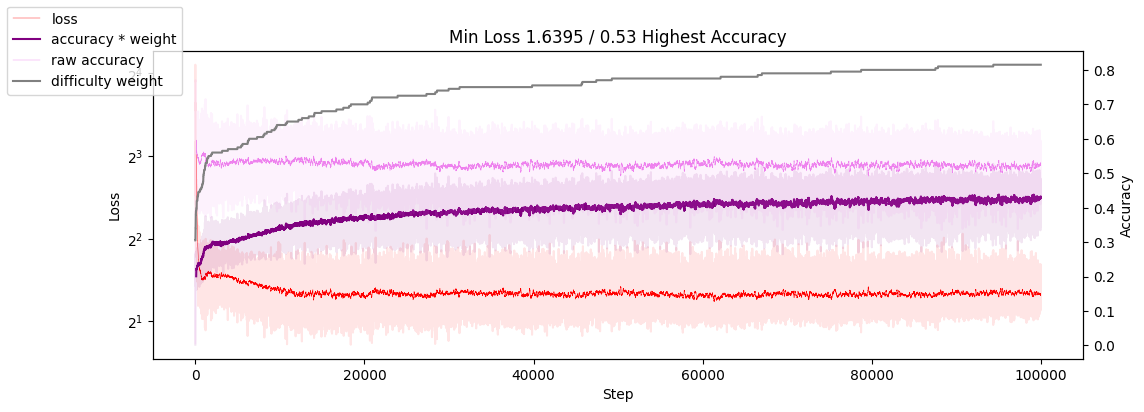

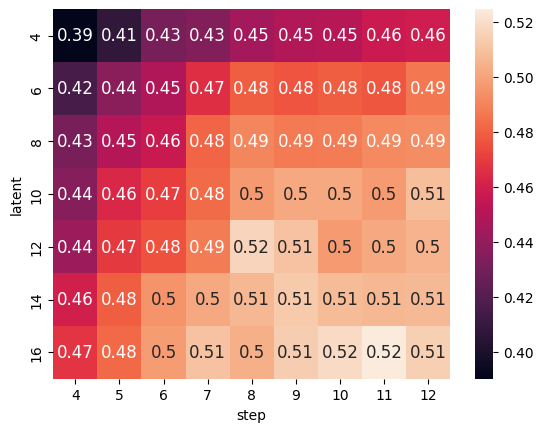

learning_rate 0.001
   31   230   829  2260  4311  6151  6216  3960  max = 8
 0.00  0.01  0.03  0.09  0.17  0.24  0.24  0.15  

averaged loss -> mean_prev:2.4449 mean:2.5330


In [ ]:
# from itertools import product
from itertools import chain, tee

experiment_counter = 0
for hp_n_latent, hp_n_step in chain(
    loop_over_extremum(exp_cfg.n_latent, exp_cfg.n_step, corner=True,  edge=False),
    loop_over_extremum(exp_cfg.n_latent, exp_cfg.n_step, corner=False, edge=True),
    ):
    experiment_counter += 1
    # if experiment_counter<21:
    #     continue
    # if hp_n_latent>5:
    #     break
    # if hp_n_step!=1:
    #     continue


    # make model
    model = ToyThinker(**model_cfg.__dict__).to(device)
    # model = torch.compile(model)

    # init tracker
    loss_tracker = []
    acc_tracker = []
    match_counter = MatchCount(data_cfg.seq_len+1)
    best_loss = float('inf')

    # init optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=run_cfg.learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=0.0005, verbose=True)

    # init dataset/loader
    data_cfg.batch = run_cfg.batch
    # dataset = NumbersComputeDataset(data_cfg)
    dataset = NumbersCopyDataset(**data_cfg.__dict__)

    batch_size = 1 # 1024
    # dataloader = DataLoader(dataset, batch_size=batch_size, num_workers=4, pin_memory=True)
    NumbersCopyDataset.reset(target_len=3) # target_len=0.5

    # reset before train
    optimizer.zero_grad()
    model.train()

    from time import time
    start_time = time()
    # for idx, (inputs,targets) in enumerate(dataloader):
    for idx, (inputs,targets) in enumerate(dataset):#(chain(*tee(dataset, 2))): # mini data loader :-)
        end_dataloading_time = time()
        # inputs,targets = inputs.to(device), targets.to(device)
        inputs,targets = inputs.to(device, non_blocking=True), targets.to(device, non_blocking=True)
        # inputs,targets = inputs[0].to(device, non_blocking=True), targets[0].to(device, non_blocking=True)
        batch_size = inputs.size(0)

        n_latent = CfgNode.sample_(hp_n_latent)
        n_step   = CfgNode.sample_(hp_n_step)

        read_step = n_step - 1 # remove on output step

        #### Toy model
        # with torch.autocast(device_type="cpu", dtype=torch.bfloat16):

        n_target = targets.size(1)
        outs = model(inputs, targets, n_latent, n_step, read_step,
                     is_full_ar = True, is_output_ar = False, output_step=1) # n_keep_output=1, n_memory=1e4
        # outputs, logits, probes, outputs_ar, logits_ar, probes_ar = outs
        logits = outs[1][:,-1,:,:].detach()
        # (self, x: Tensor, target = None,
        #                 n_latent = None, n_step: int = 1, read_step: int = 1e4, n_keep_output:int = 1,
        #                 n_memory:int = 1e4, output_step:int = 1, knowledge_trigger = torch.LongTensor([]),
        #                 is_full_ar:bool = False, is_output_ar:bool = False)

        # compute loss
        # n = targets.size(1)
        # seq_len = min(n, max(1, int((n_latent/16 + n_step/11)/2*n * 1.2))) if np.random.random() < 0.8 else n
        seq_len = None
        loss, logs_ = all_losses_compute(outs, targets, target_emb=None, last_step_only = False, seq_len = seq_len)

        end_forward_loss_time = time()

        accuracy = (targets == torch.argmax(logits, dim=2)).float().mean().item()
        match_counter.update(logits, targets)

        # curriculum learning
        NumbersCopyDataset.update_accuracy(accuracy)
        factor =  NumbersCopyDataset.get_challenge_factor()
        NumbersCopyDataset.raw_acc = accuracy
        raw_acc = accuracy
        accuracy = accuracy * factor
        if idx%51==0:
            s = np.random.randint(targets.size(0))
            correct = (targets[s,:] == torch.argmax(logits[s,:], dim=1)) #[:break_i]
            print()
            print("accuracy: %.3f raw_acc: %.3f with factor %.2f     - sample: acc:%.2f _ %d correct" % (accuracy, raw_acc, factor, correct.float().mean(), correct.sum(),))
            for i in range(targets.size(1)):
                val = targets[s,i].item()
                print(f"{val:2d}", end=', ')
                # if val == 20: break
            print()
            for j in range(i+1):
                val = torch.argmax(logits[s,j]).item()
                print(f"{val:2d}", end=', ')
            print()
            # for j in range(i+1):
            #     val = outputs_probe[s,j].item()*16
            #     print(f"{val:.2f}", end=', ')
            # print()


        # (output_loss + probe_loss).backward()
        loss.backward()

        if idx%run_cfg.acc_gradient==0 and idx>=run_cfg.acc_gradient:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            optimizer.zero_grad()
            # scheduler.step()
        if idx%100==0:
            # print(f"{idx} :: loss: {output_loss.item():.4f}, n_step: {n_step}, latent_size: {latent_size}")
            print(f"id: {idx:3d}: loss: {loss.item():.3f} accuracy: {accuracy:.2f}")

        std = dict()
        if idx%51==0:
            loss_std = np.std(loss_tracker[-50:]) / np.mean(loss_tracker[-50:])
            acc_std  = np.std(acc_tracker[-50:])  / np.mean(acc_tracker[-50:])
            std = dict(loss_std=loss_std, acc_std=acc_std)
            print(f"\n~ ~ ~  loss_std:{loss_std:.4f} acc_std:{acc_std:.4f}  ~ ~ ~")
            # if loss_std>0.1:
            #     scheduler.step()

        # loss_tracker.append(outputs_probe_loss.item())
        loss_tracker.append(loss.item())
        acc_tracker.append(accuracy)
        logs.append(dict(
            loss = loss.item(),
            # probe_loss = probe_loss.item(),
            accuracy = accuracy,
            latent = n_latent,
            step = n_step,
            iteration = idx,
            experiment = experiment_counter,
            factor = factor,
            raw_acc = raw_acc,
            token_pred_ar = [l['loss'] for l in logs_ if l['name']=='token_pred_ar'][0]
            # token_pred_ar = [l[1] for l in logs_ if l[0]=='token_pred_ar'][0]
            # **std
        ))

        if idx%200==0 and idx>=100:
            from IPython.display import clear_output
            clear_output()

            print(f"exp:{experiment_counter}, n_latent:{n_latent}, n_step:{n_step}")
            plot_loss_and_accuracy(logs, y_log=True)
            plot_hp_heatmap(logs, aggr='top10_avg') # aggr='max') # top10_avg
            plt.show()

            # with open('./train_param.txt','r') as f:
            #     lr = float(f.read())*learing_rate

            # print('========== learing_rate:', lr)
            # for param_group in optimizer.param_groups:
            #     param_group['lr'] = lr

            print('learning_rate', optimizer.param_groups[0]['lr'])
            print(match_counter,'\n')
            match_counter = MatchCount(inputs.size(1)+1)

            mean = np.mean(loss_tracker[-50:])
            mean_prev = np.mean(loss_tracker[-100:-50])
            print(f'averaged loss -> mean_prev:{mean_prev:.4f} mean:{mean:.4f}')

        if idx%100==0 and idx>=100:
            mean_loss = np.mean(loss_tracker[-100:])
            if mean_loss < best_loss:
                best_loss = mean_loss
                torch.save(model.state_dict(), "model.pt")
                print(f'save best model mean_loss={mean_loss:.4f}')
            # scheduler.step()

        # if idx%200==0 and idx>=200:
        #     mean_loss = np.mean(loss_tracker[-200:])
        #     if mean_loss > best_loss:
        #         print('loss increase, load best model')
        #         model.load_state_dict(torch.load("model.pt"))
        #         # scheduler.step()

        # if idx>=200 and (loss_tracker[-1]/loss_tracker[-10])>1.5:
        #     print('loss peak increase, load best model')
        #     model.load_state_dict(torch.load("model.pt"))
        #     # scheduler.step()

        if idx%101==0:
            print(f"Timing\n"
                f"{end_dataloading_time-start_time:.6f} data loading\n"
                f"{end_forward_loss_time-end_dataloading_time:.6f} forward+loss\n"
                f"{time()-end_forward_loss_time:.6f} backward+remaining\n"
            )
            # !nvidia-smi
            # import code; code.interact(local=locals())

        if idx>run_cfg.max_iter:
            break
        start_time = time()


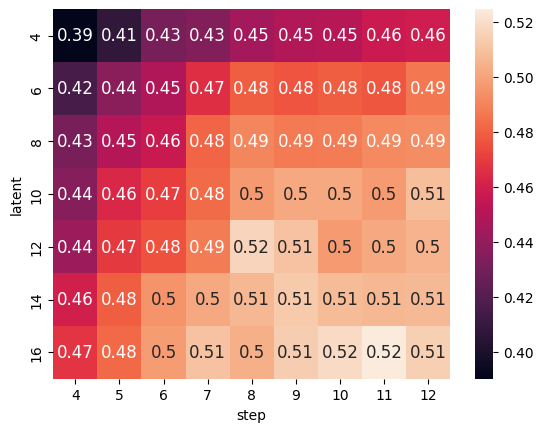

In [ ]:
plot_hp_heatmap(logs, aggr='top10_avg')

In [ ]:
import pandas as pd

df = pd.DataFrame(logs)
df.token_pred_ar = df.token_pred_ar.astype(float)
df

,loss,accuracy,latent,step,iteration,experiment,factor,raw_acc,token_pred_ar
0,14.995727,0.002145,8,5,0,1,0.305,0.007031,3.883658
1,16.289787,0.002859,10,8,1,1,0.305,0.009375,3.856219
2,17.213665,0.002145,16,4,2,1,0.305,0.007031,3.784566
3,14.936090,0.005480,8,7,3,1,0.305,0.017969,3.657175
4,14.749944,0.023590,10,10,4,1,0.305,0.077344,3.532950
...,...,...,...,...,...,...,...,...,...
99997,2.784721,0.383941,4,10,99997,1,0.815,0.471094,0.001668
99998,3.019515,0.359109,8,4,99998,1,0.815,0.440625,0.000888
99999,2.608404,0.431695,6,12,99999,1,0.815,0.529688,0.003286
100000,2.336620,0.444430,12,7,100000,1,0.815,0.545313,0.000862


In [ ]:
df = df.groupby(['latent', 'step'])

def avg_top_k(series, k):
    return series.nlargest(k).mean()
df = df.agg(avg_top_k, k=2)
df

loss  accuracy  iteration  experiment  factor   raw_acc  \
latent step                                                                
4      4     6.134654  0.390320    99749.5         1.0   0.815  0.627344   
       5     7.945947  0.407930    99904.5         1.0   0.815  0.629297   
       6     4.602084  0.430898    99945.5         1.0   0.815  0.643359   
       7     6.151345  0.434687    99868.5         1.0   0.815  0.678125   
       8     7.345827  0.445309    99985.5         1.0   0.815  0.628516   
...               ...       ...        ...         ...     ...       ...   
16     8     9.213028  0.503836    99908.0         1.0   0.815  0.655469   
       9     5.559963  0.514062    99934.5         1.0   0.815  0.691797   
       10    6.058634  0.518518    99842.5         1.0   0.815  0.669531   
       11    7.239096  0.524609    99854.0         1.0   0.815  0.680469   
       12    6.823494  0.514375    99931.5         1.0   0.815  0.670703   

             token_pred_ar  
latent step                 
4      4          1.385006  
       5          1.826032  
       6          0.691320  
       7          1.430656  
       8          1.737670  
...                    ...  
16     8          2.378137  
       9          1.211844  
       10         1.252093  
       11         1.557708  
       12         1.647734  

[63 rows x 7 columns]

In [ ]:
df.max()

,0
loss,12.334518
accuracy,0.524609
iteration,99989.000000
experiment,1.000000
factor,0.815000
raw_acc,0.716797
token_pred_ar,3.057114


In [ ]:
import pandas as pd
import seaborn as sns

def plot_hp_heatmap(logs, use_last_n_batch=200, aggr='max', ax=None):
    if isinstance(logs, pd.DataFrame): df = logs
    else: df = pd.DataFrame(logs)

    if len(df) < use_last_n_batch:
        return

    # Group the data by the latent and step columns.
    df = df.groupby(['latent', 'step'])
    if aggr == 'mean':
        df = df.mean()
    elif aggr == 'max':
        df = df.max()
    elif aggr == 'top10_avg':
        # def avg_top_k(series, k):
        #     return series.nlargest(k).mean()
        df = df.nlargest(10).mean() #.agg(avg_top_k, k=2)
    else:
        assert f'Invalid argument aggr={aggr}'
    df = df.reset_index().pivot(index="latent", columns="step", values="accuracy")

    if ax is None: fig, ax = plt.subplots()

    # Plot a heatmap of the average loss.
    sns.heatmap(df, annot=True, ax=ax, annot_kws={"size": 12})

plot_hp_heatmap(logs, use_last_n_batch=200, aggr='top10_avg', ax=None)

AttributeError: 'DataFrameGroupBy' object has no attribute 'nlargest'

In [ ]:
def plot_loss_and_accuracy(logs, experiment=None, title=None, ax=None, y_log=False):
    # Create a DataFrame from the list of dictionaries.
    if isinstance(logs, pd.DataFrame): df = logs
    else: df = pd.DataFrame(logs)

    # Filter current experiment
    if 'experiment' in df.columns:
        if experiment is None:
            experiment = df.iloc[-1].experiment
        df = df[df.experiment == experiment]

    if ax is None: fig, ax = plt.subplots()

    # Plot the loss values on the left y-axis.
    sns.lineplot(data=df, x=df.index, y='loss', color='red', alpha=.1, ax=ax) #, hue='step')
    sns.lineplot(data=df, x=df.index, y=df.loss.rolling(100).mean(), label='loss', color='red', linewidth=.3, ax=ax)
    # if 'factor' in df.columns: # no that use full to visualize
    #     loss_factor = df.loss*df.factor
    #     sns.lineplot(data=df, x=df.index, y=loss_factor,  color='darkorange', alpha=.1, ax=ax)
    #     sns.lineplot(data=df, x=df.index, y=loss_factor.rolling(100).mean(), label='loss * weight', color='darkorange', ax=ax)
    # sns.lineplot(data=df, x='iteration', y='probe_loss', color='peru', ax=ax)
    ax.set_ylabel('Loss')
    if y_log: plt.yscale('log',base=2)

    # Plot the accuracy values on the right y-axis.
    ax2 = ax.twinx()
    sns.lineplot(data=df, x=df.index, y='accuracy', color='purple', alpha=.1, ax=ax2)
    sns.lineplot(data=df, x=df.index, y=df.accuracy.rolling(100).mean(), label='accuracy * weight', color='purple',  ax=ax2)
    if 'raw_acc' in df.columns:
        sns.lineplot(data=df, x=df.index, y='raw_acc',  color='violet',  alpha=.1, ax=ax2)
        sns.lineplot(data=df, x=df.index, y=df.raw_acc.rolling(100).mean(),  label='raw accuracy',  color='violet', linewidth=.3, ax=ax2)

    if 'factor' in df.columns:   sns.lineplot(data=df, x=df.index, y='factor',   label='difficulty weight',   color='gray', ax=ax2)

    # if 'loss_std' in df.columns: sns.lineplot(data=df, x=df.index, y='loss_std', label='loss_std', color='wheat', ax=ax2)
    # if 'acc_std' in df.columns:  sns.lineplot(data=df, x=df.index, y='acc_std',  label='acc_std',  color='lavender', ax=ax2)
    if 'token_pred_ar' in df.columns:  sns.lineplot(data=df, x=df.index, y='token_pred_ar',  label='token_pred_ar',  color='lavender', ax=ax2)

    ax2.set_ylabel('Accuracy')

    best_loss = df.loss.min()
    best_acc = df.accuracy.max()

    # Set the title of the plot.
    if title: ax.set_title(title)
    else: ax.set_title(f"Min Loss {best_loss:.4f} / {best_acc:.2f} Highest Accuracy")
    ax.set_xlabel('Step')

    # # Set the width of the plot.
    ax.figure.set_size_inches(12, 4)
    # sns.move_legend(ax2, "lower right")
    ax.get_legend().set_visible(False)
    ax2.get_legend().set_visible(False)
    fig.legend(loc = "upper left") # "lower right"


#-------------STOP

In [ ]:
inputs.shape, targets.shape

In [ ]:
outputs, logits, probes, outputs_ar, logits_ar, probes_ar = outs

In [ ]:
logits.shape

In [ ]:
plot_loss_and_accuracy(logs, y_log=True)

In [ ]:
df = pd.DataFrame(logs)
df

In [ ]:
len(logs)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_loss_and_accuracy(logs, experiment=None, title=None, ax=None, y_log=False):
    # Create a DataFrame from the list of dictionaries.
    if isinstance(logs, pd.DataFrame): df = logs
    else: df = pd.DataFrame(logs)

    # Filter current experiment
    if 'experiment' in df.columns:
        if experiment is None:
            experiment = df.iloc[-1].experiment
        df = df[df.experiment == experiment]

    if ax is None: fig, ax = plt.subplots()

    # Plot the loss values on the left y-axis.
    sns.lineplot(data=df, x=df.index, y='loss', color='red', alpha=.1, ax=ax) #, hue='step')
    sns.lineplot(data=df, x=df.index, y=df.loss.rolling(100).mean(), label='loss', color='red', linewidth=.3, ax=ax)
    # if 'factor' in df.columns: # no that use full to visualize
    #     loss_factor = df.loss*df.factor
    #     sns.lineplot(data=df, x=df.index, y=loss_factor,  color='darkorange', alpha=.1, ax=ax)
    #     sns.lineplot(data=df, x=df.index, y=loss_factor.rolling(100).mean(), label='loss * weight', color='darkorange', ax=ax)
    # sns.lineplot(data=df, x='iteration', y='probe_loss', color='peru', ax=ax)
    ax.set_ylabel('Loss')
    if y_log: plt.yscale('log',base=2)

    # Plot the accuracy values on the right y-axis.
    ax2 = ax.twinx()
    sns.lineplot(data=df, x=df.index, y='accuracy', color='purple', alpha=.1, ax=ax2)
    sns.lineplot(data=df, x=df.index, y=df.accuracy.rolling(100).mean(), label='accuracy * weight', color='purple',  ax=ax2)
    if 'raw_acc' in df.columns:
        sns.lineplot(data=df, x=df.index, y='raw_acc',  color='violet',  alpha=.1, ax=ax2)
        sns.lineplot(data=df, x=df.index, y=df.raw_acc.rolling(100).mean(),  label='raw accuracy',  color='violet', linewidth=.3, ax=ax2)

    if 'factor' in df.columns:   sns.lineplot(data=df, x=df.index, y='factor',   label='difficulty weight',   color='gray', ax=ax2)

    if 'loss_std' in df.columns: sns.lineplot(data=df, x=df.index, y='loss_std', label='loss_std', color='wheat', ax=ax2)
    if 'acc_std' in df.columns:  sns.lineplot(data=df, x=df.index, y='acc_std',  label='acc_std',  color='lavender', ax=ax2)

    ax2.set_ylabel('Accuracy')

    best_loss = df.loss.min()
    best_acc = df.accuracy.max()

    # Set the title of the plot.
    if title: ax.set_title(title)
    else: ax.set_title(f"Min Loss {best_loss:.4f} / {best_acc:.2f} Highest Accuracy")
    ax.set_xlabel('Step')

    # # Set the width of the plot.
    ax.figure.set_size_inches(12, 4)
    # sns.move_legend(ax2, "lower right")
    ax.get_legend().set_visible(False)
    ax2.get_legend().set_visible(False)
    fig.legend(loc = "upper left") # "lower right"

def plot_hp_heatmap(logs, use_last_n_batch=200, aggr='max', ax=None):
    if isinstance(logs, pd.DataFrame): df = logs
    else: df = pd.DataFrame(logs)

    if len(df) < use_last_n_batch:
        return

    # Group the data by the latent and step columns.
    df = df.groupby(['latent', 'step'])
    if aggr == 'mean':
        df = df.mean()
    elif aggr == 'max':
        df = df.max()
    else:
        assert f'Invalid argument aggr={aggr}'
    df = df.reset_index().pivot(index="latent", columns="step", values="accuracy")

    if ax is None: fig, ax = plt.subplots()

    # Plot a heatmap of the average loss.
    sns.heatmap(df, annot=True, ax=ax, annot_kws={"size": 22})

def compare_experiments(logs):
    if isinstance(logs, pd.DataFrame): df = logs
    else: df = pd.DataFrame(logs)

    unique_experiments = df.experiment.unique()
    num_experiments = len(unique_experiments)

    fig = plt.figure(figsize=(25, 15))

    # Create a 2x2 grid with the heatmap at the center
    grid = GridSpec(5, 4, figure=fig)
    heatmap_ax = plt.subplot(grid[1:-1, 1:-1])
    plot_hp_heatmap(df, aggr='max', ax=heatmap_ax)

    for i, exp_id in enumerate(unique_experiments):
        df_exp = df[df.experiment == exp_id]
        step, latent = int(df_exp.iloc[0].step), int(df_exp.iloc[0].latent)
        title = f"Loss and Accuracy w/ hyperparam = step: {step:.0f} | latent: {latent:.0f}"
        plot_loss_and_accuracy(df_exp, None, title=title, ax=plt.subplot(grid[latent-4, step-1]))


    # # Set the figure size for each subplot
    # for ax in [heatmap_ax] + loss_accuracy_axs:
    #     box = ax.get_position()
    #     ax.set_position([box.x0, box.y0, box.width * 0.9, box.height])

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()

plot_loss_and_accuracy(logs[:2000], y_log=True)

In [ ]:
import gc

del logs #loss #match_counter
gc.collect()

In [ ]:
# %reset
# %whos
# for name in vars().keys():
#   print(name)
# globals()

In [ ]:
import pandas as pd

df = pd.DataFrame(logs)
# df.to_csv('logs-copy-hdim16-9k_param-20Dec.csv', index=0)

In [ ]:
df.columns

In [ ]:
# @title
import pandas as pd
import seaborn as sns

def plot_loss_and_accuracy(logs, experiment=None, title=None):
    # Create a DataFrame from the list of dictionaries.
    if isinstance(logs, pd.DataFrame): df = logs
    else: df = pd.DataFrame(logs)

    # Filter current experiment
    if 'experiment' in df.columns:
        if experiment == None:
            experiment = df.iloc[-1].experiment
        df = df[df.experiment == experiment]

    # Plot the loss values on the left y-axis.
    sns.lineplot(data=df, x='iteration', y='loss', color='orange') #, hue='step')
    # sns.lineplot(data=df, x='iteration', y='probe_loss', color='peru') #, hue='step')
    plt.ylabel('Loss')
    # plt.yscale('log',base=2)

    # Plot the accuracy values on the right y-axis.
    plt.twinx()
    sns.lineplot(data=df, x='iteration', y='accuracy', color='purple') #, hue='latent')
    plt.ylabel('Accuracy')

    # Set the title of the plot.
    if title: plt.title(title)
    else: plt.title('Loss and Accuracy')
    plt.xlabel('Step')


    # Set the width of the plot.
    plt.gcf().set_size_inches(12, 4)

    # Show the plot.
    plt.show()

    #plot_hp_heatmap(logs)

def plot_hp_heatmap(logs, use_last_n_batch=200, aggr='max'):
    if isinstance(logs, pd.DataFrame): df = logs
    else: df = pd.DataFrame(logs)

    if len(df)<use_last_n_batch: return

    # Group the data by the latent and step columns.
    # df = df[-use_last_n_batch:].groupby(['latent', 'step'])
    df = df.groupby(['latent', 'step'])
    if aggr=='mean':
        df = df.mean()
    elif aggr=='max':
        df = df.max()
    else:
        assert f'Invalid argument aggr={aggr}'
    df = df.reset_index().pivot(index="latent", columns="step", values="accuracy")

    # if len(df)<2: return #not interresting
    # print('i')

    # Plot a heatmap of the average loss.
    sns.heatmap(df, annot=True)

    # Show the plot.
    plt.show()


for exp_id in df.experiment.unique():
    df_exp = df[df.experiment==exp_id]
    step, latent = df_exp.iloc[0].step, df_exp.iloc[0].latent
    title = f"Loss and Accuracy w/ hyperparam = step: {step:.0f} | latent: {latent:.0f}"
    plot_loss_and_accuracy(df_exp, None, title=title)

# plot_hp_heatmap(df, aggr='max')

In [ ]:
def compare_experiments(logs):
    if isinstance(logs, pd.DataFrame): df = logs
    else: df = pd.DataFrame(logs)

    unique_experiments = df.experiment.unique()
    num_experiments = len(unique_experiments)

    fig = plt.figure(figsize=(25, 15))

    # Create a 2x2 grid with the heatmap at the center
    grid = GridSpec(5, 4, figure=fig)
    heatmap_ax = plt.subplot(grid[1:-1, 1:-1])
    plot_hp_heatmap(df, aggr='max', ax=heatmap_ax)

    for i, exp_id in enumerate(unique_experiments):
        df_exp = df[df.experiment == exp_id]
        step, latent = int(df_exp.iloc[0].step), int(df_exp.iloc[0].latent)
        title = f"Loss and Accuracy w/ hyperparam = step: {step:.0f} | latent: {latent:.0f}"
        plot_loss_and_accuracy(df_exp, None, title=title, ax=plt.subplot(grid[latent-4, step-1]))


    # # Set the figure size for each subplot
    # for ax in [heatmap_ax] + loss_accuracy_axs:
    #     box = ax.get_position()
    #     ax.set_position([box.x0, box.y0, box.width * 0.9, box.height])

    # Adjust layout and show the plot
    plt.tight_layout()
    plt.show()



In [ ]:
plot_hp_heatmap(logs)

In [ ]:
logits.shape, logits[:,0,:,:].permute(0,2,1).shape, targets.shape # output_probe.shape

In [ ]:
output_loss = torch.nn.functional.cross_entropy(logits[:,0,:,:].permute(0,-1,1,2), targets.long())

In [ ]:
logits.shape

In [ ]:
output_probe.shape

In [ ]:
# def train(r_cfg, dataset, model):

In [ ]:
data_cfg.batch = run_cfg.batch
dataset = NumbersComputeDataset(data_cfg)

# dataset = NumbersCopyDataset(low=0, high=16, size=(20,), flip=False, roll=True, sort=False)
# dataset = NumbersComputeDataset(TASK_SCHEME)

train(run_cfg, dataset, model)

# 🔎 Post training evaluation

In [ ]:
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# Generate some sample data similar to your post
n = len(loss_tracker)
X = np.arange(1,n+1)
Y = np.array(acc_tracker)

Y2 = savgol_filter(Y, 1000, 3)

i = 0 # 10000
plt.figure(figsize=(12,5))
plt.plot(X[i:],  Y[i:], linestyle='-', linewidth=2,alpha=.5)
# plt.plot(X[i:], Y2[i:], color='r')
plt.yscale('log',base=10)
plt.xscale('log',base=10)
plt.gca().invert_xaxis()

plt.show()

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

fig=px.line(x=X,y=Y2, log_y=True)
fig.add_scatter(x=X, y=Y, mode='lines')
fig.show()